# Problem Set 4


In [96]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 Simple regressions

### Q1

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.api import add_constant
from sklearn.linear_model import Lasso

In [98]:
ahdata = pd.read_csv('ad_heterog.csv')
ahdata.head()

,revenue,treatment,demographic_1,demographic_2,demographic_3,demographic_4,demographic_5,demographic_6,demographic_7,demographic_8,...,demographic_21,demographic_22,demographic_23,demographic_24,demographic_25,demographic_26,demographic_27,demographic_28,demographic_29,demographic_30
0,5.504899,0,1,1,1,0,0,1,1,1,...,1,1,1,1,0,1,1,1,0,1
1,5.554275,1,0,1,1,0,0,0,1,0,...,0,0,0,1,1,0,1,1,1,0
2,5.219492,0,0,1,1,0,0,1,1,1,...,0,1,0,1,0,1,1,0,0,1
3,4.565855,0,1,0,0,0,1,1,0,1,...,1,0,0,1,0,1,0,0,1,0
4,5.020636,0,1,1,0,1,0,0,1,1,...,1,1,0,0,1,1,0,0,0,1


In [99]:
revenue_treatment_reg = smf.ols(formula = 'revenue ~ treatment', data = ahdata).fit()
print(revenue_treatment_reg.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.280
Method:                 Least Squares   F-statistic:                     779.2
Date:                Sun, 16 Mar 2025   Prob (F-statistic):          4.50e-145
Time:                        03:46:34   Log-Likelihood:                -1532.5
No. Observations:                2000   AIC:                             3069.
Df Residuals:                    1998   BIC:                             3080.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1082      0.016    315.942      0.0

The intercept is 5.1082 and its p-value is 0.000, which is much smaller than 0.05. It represents the average revenue for the control group, when the ad is not shown, is 5.1082.
The coefficient of treatment is 0.6508 and its p-value is 0.000, which is much smaller than 0.05. It represented the difference in average revenue between the control group and treatment group. Since 0.6508 is positive, the ad targeting could help bring 0.6508 increase in the revenue compared with those who didn't see the ads.

### Q2

We should not show the ad becasue 0.6508 < 0.7 and 0.6508 is the estimated increase in revenue due to the ad and the cost is 0.7 dollars to show the ad. Thus, ad targeting doesn't bring enough additional revenue to cover the cost and so we should not show the ad.

## 2 Lasso with interactions

### Q1

In [100]:
# extract columns pertaining to demographic information (all columns except first two)
demo_matrix = ahdata.iloc[:,2:]
# generate interactions of each demographic variable with the treatment variable
demo_treat_matrix = demo_matrix.multiply(ahdata['treatment'], axis="index")
demo_treat_matrix.columns = demo_treat_matrix.columns.str.replace("demographic", "treat_demo")
# generate treatment variable that is outside of data-frame (useful below)
treatment = ahdata['treatment']

In [101]:
X = pd.concat([treatment, demo_treat_matrix], axis=1)
y = ahdata["revenue"]

In [102]:
X.head()

,treatment,treat_demo_1,treat_demo_2,treat_demo_3,treat_demo_4,treat_demo_5,treat_demo_6,treat_demo_7,treat_demo_8,treat_demo_9,...,treat_demo_21,treat_demo_22,treat_demo_23,treat_demo_24,treat_demo_25,treat_demo_26,treat_demo_27,treat_demo_28,treat_demo_29,treat_demo_30
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,0,1,1,0,0,0,1,0,1,...,0,0,0,1,1,0,1,1,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [103]:
y.head()

,revenue
0,5.504899
1,5.554275
2,5.219492
3,4.565855
4,5.020636


In [104]:
X.describe()

,treatment,treat_demo_1,treat_demo_2,treat_demo_3,treat_demo_4,treat_demo_5,treat_demo_6,treat_demo_7,treat_demo_8,treat_demo_9,...,treat_demo_21,treat_demo_22,treat_demo_23,treat_demo_24,treat_demo_25,treat_demo_26,treat_demo_27,treat_demo_28,treat_demo_29,treat_demo_30
count,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.0000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.481000,0.231000,0.2440,0.239000,0.234000,0.250500,0.239000,0.2440,0.242500,0.249500,...,0.241000,0.232000,0.232000,0.237500,0.245000,0.246500,0.241000,0.227500,0.239000,0.245000
std,0.499764,0.421578,0.4296,0.426579,0.423478,0.433409,0.426579,0.4296,0.428702,0.432832,...,0.427797,0.422215,0.422215,0.425658,0.430195,0.431081,0.427797,0.419323,0.426579,0.430195
min,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.0000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.0000,0.000000,0.000000,1.000000,0.000000,0.0000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [105]:
y.describe()

,revenue
count,2000.000000
mean,5.421198
std,0.613984
min,3.378275
25%,5.016599
50%,5.405246
75%,5.821808
max,7.368269


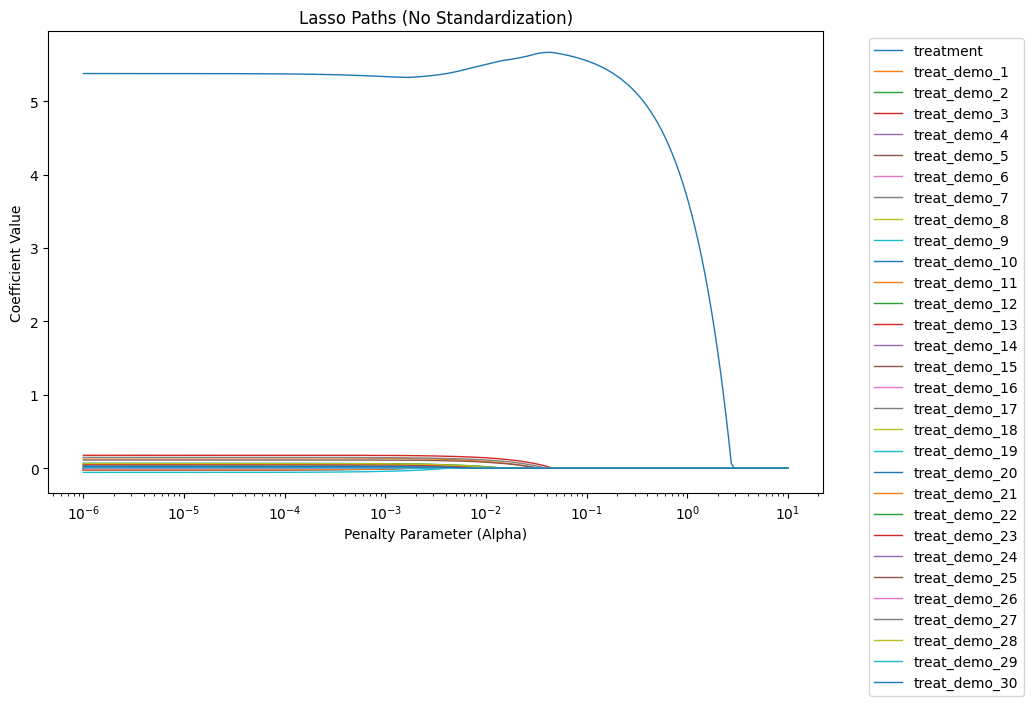

In [106]:
alphas = np.logspace(-6, 1, 250)
lasso_coefs = []

# Fit Lasso for each alpha (disable intercept and standardization)
for alpha in alphas:
    lasso = Lasso(
        alpha=alpha,
        fit_intercept=False,  # Disable centering (critical for no standardization)
        max_iter=10000
    )
    lasso.fit(X, y)
    lasso_coefs.append(lasso.coef_)

plt.figure(figsize=(10, 6))
for i,coef_vals in enumerate(np.array(lasso_coefs).T):
    plt.plot(alphas, coef_vals, label=X.columns[i], linewidth=1)

plt.xscale('log')
plt.gca()
plt.xlabel("Penalty Parameter (Alpha)")
plt.ylabel("Coefficient Value")
plt.title("Lasso Paths (No Standardization)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


The first line exhibits non-monotonic behavior in the graph above. This is because Lasso regression balances the tradeoff between bias and variance in the resulting coefficients and the treatment variable is correlated with the interaction terms since the interaction terms are generated by the multiplication of treatment and demographics variables. When alpha is very small, Lasso behaves similarly to ordinary least squares. All coefficients are non-zero, which means that all of the treatment variable and the interaction terms contribute to explaining y. At this time, the treatment coefficient is moderate, as the interaction terms also has some power to explain y. Moreover, as alpha increases, Lasso penalizes larger coefficients, causing some interaction terms to start shrinking toward zero. The treatment coefficient will increase to compensate for the disappearing interaction terms effects on y because the interaction terms are being suppressed. And then there is a threshold where the treatment coefficient reaches its highest value since most interaction terms have been shrink close to zero and the model gives greater importance to the treatment effect. The peak of the blue line is that threshold. As alpha continues to increase, the coefficient of the treatment starts decreasing towards 0 because it is experiencing stronger penalization and Lasso favors sparsity.

### Q2

In [107]:
from sklearn.linear_model import LassoCV

nfolds  = 10
lassocv = LassoCV(alphas=alphas, cv = nfolds, max_iter = 10000)
lassocv.fit(X,y)


optimal_alpha =lassocv.alpha_
non_zero_coefs = lassocv.coef_[lassocv.coef_ != 0]
non_zero_features =X.columns[lassocv.coef_ != 0]


In [108]:
print("Optimal alpha:", optimal_alpha)
print("Non-zero coefficients:")
for feature, coef in zip(non_zero_features, non_zero_coefs):
    print(f"{feature}: {coef:.4f}")

Optimal alpha: 0.005138582972943202
Non-zero coefficients:
treatment: 0.2850
treat_demo_1: 0.1140
treat_demo_3: 0.1580
treat_demo_7: 0.1277
treat_demo_9: 0.0392
treat_demo_16: 0.0061
treat_demo_18: 0.0215
treat_demo_20: 0.0116
treat_demo_22: 0.0404
treat_demo_23: 0.0234
treat_demo_25: 0.0974
treat_demo_27: 0.0101
treat_demo_28: 0.0382
treat_demo_30: 0.0074


The regularization strength (alpha = 0.00514) indicates moderate regularization, balancing model complexity and overfitting.

The treatment coefficient is 0.2850, which means that the treatment (ads) effect on revenue is positive.

The non-zero coefficients represent the important predictive variables in the model. Since the above shows the variables with non-zero coefficients, it means that the effect of treatment on revenue varies significantly based on these demographic feature. The high positive coefficients means certain groups respond more strongly to treatment, providing insights for targeted intervention.

Larger interaction coefficients indicate stronger treatment effects for those groups. Thus, we conclude that groups with large positive interaction terms such as treat_demo_3, treat_demo_1, treat_demo_7, and treat_demo_25 can bring significantly more revenue from the treatment. These are main candidates for targeted campaigns.

Groups with no interaction terms, such as demographics 2, 4, 5, 6, etc. may not need specialized targeting.

Some interactions such as treat_demo_16 and its coefficient is 0.0061 are statistically retained but have minimal practical impact. Thus, we should focus on larger effects first to increase our revenue and ensure the efficiency of the adds and if the time and costs are allowed, we could futher consider target these groups, including treat_demo_9, 16, 18, 20,22, 23, 27, 28,30.


## 3 Lasso with baseline and interacted demographics

### Q1

In [109]:
X_final = pd.concat([treatment, demo_matrix, demo_treat_matrix], axis=1)

In [110]:
X_final.describe()

,treatment,demographic_1,demographic_2,demographic_3,demographic_4,demographic_5,demographic_6,demographic_7,demographic_8,demographic_9,...,treat_demo_21,treat_demo_22,treat_demo_23,treat_demo_24,treat_demo_25,treat_demo_26,treat_demo_27,treat_demo_28,treat_demo_29,treat_demo_30
count,2000.000000,2000.000000,2000.0000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.481000,0.490000,0.5050,0.5050,0.481500,0.506500,0.507500,0.509500,0.492500,0.505500,...,0.241000,0.232000,0.232000,0.237500,0.245000,0.246500,0.241000,0.227500,0.239000,0.245000
std,0.499764,0.500025,0.5001,0.5001,0.499783,0.500083,0.500069,0.500035,0.500069,0.500095,...,0.427797,0.422215,0.422215,0.425658,0.430195,0.431081,0.427797,0.419323,0.426579,0.430195
min,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.0000,0.0000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,1.0000,1.0000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.0000,1.0000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.0000,1.0000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [111]:
nfolds  =  10
lassocv2 = LassoCV(alphas = alphas, cv = nfolds, max_iter = 10000)
lassocv2.fit(X_final,y)

LassoCV(alphas=array([1.00000000e-06, 1.06687233e-06, 1.13821656e-06, 1.21433175e-06,
       1.29553694e-06, 1.38217250e-06, 1.47460159e-06, 1.57321163e-06,
       1.67841595e-06, 1.79065553e-06, 1.91040083e-06, 2.03815378e-06,
       2.17444986e-06, 2.31986038e-06, 2.47499484e-06, 2.64050350e-06,
       2.81708011e-06, 3.00546480e-06, 3.20644723e-06, 3.42086981e-06,
       3.64963133e-06, 3.89369066e-0...
       2.56825744e+00, 2.74000278e+00, 2.92323314e+00, 3.11871654e+00,
       3.32727237e+00, 3.54977481e+00, 3.78715651e+00, 4.04041247e+00,
       4.31060425e+00, 4.59886438e+00, 4.90640114e+00, 5.23450359e+00,
       5.58454702e+00, 5.95799867e+00, 6.35642389e+00, 6.78149274e+00,
       7.23498693e+00, 7.71880733e+00, 8.23498193e+00, 8.78567432e+00,
       9.37319280e+00, 1.00000000e+01]),
        cv=10, max_iter=10000)

In [112]:
optimal_alpha2 = lassocv2.alpha_
print(f"Optimal penalty parameter (alpha): {optimal_alpha2}")

# Extract coefficients at optimal alpha
optimal_coefs2 = pd.Series(lassocv2.coef_, index=X_final.columns)

# Extract non-zero coefficients
non_zero_coefs_extended2 = optimal_coefs2[optimal_coefs2 != 0]
print("\nNon-zero coefficients at optimal alpha:")
print(non_zero_coefs_extended2)


Optimal penalty parameter (alpha): 0.006239944441689813

Non-zero coefficients at optimal alpha:
treatment         0.455881
demographic_1     0.137533
demographic_2    -0.002266
demographic_7     0.015889
demographic_9     0.033720
demographic_11   -0.013460
demographic_22    0.031727
demographic_23    0.020321
demographic_25    0.067774
demographic_28    0.013587
treat_demo_3      0.154432
treat_demo_7      0.107407
treat_demo_9      0.001916
treat_demo_16     0.000935
treat_demo_18     0.016872
treat_demo_20     0.007877
treat_demo_22     0.004190
treat_demo_25     0.025402
treat_demo_27     0.005543
treat_demo_28     0.020127
treat_demo_30     0.002694
dtype: float64


In [113]:
# Extract coefficients for treatment, demographic_3, demographic_7, treat_demo_3, treat_demo_7
coeff_treatment = optimal_coefs2.get('treatment')
coeff_demo_3 = optimal_coefs2.get('demographic_3')
coeff_treat_demo_3 = optimal_coefs2.get('treat_demo_3')
coeff_demo_7 = optimal_coefs2.get('demographic_7')
coeff_treat_demo_7 = optimal_coefs2.get('treat_demo_7')

tedemo_3 = coeff_treatment + coeff_treat_demo_3
tedemo_7 = coeff_treatment + coeff_treat_demo_7

print("Treatment Effect (Demo 3)", tedemo_3)
print("Treatment Effect (Demo 7)", tedemo_7)

Treatment Effect (Demo 3) 0.61031290874891
Treatment Effect (Demo 7) 0.5632881261883611


Based on the result, we know that the coefficient of the treatment is 0.455881. Since demographic_7 is 0.015889, which means that after accounting for treatment and other explanatory variables, the customer group with demographic_7 can bring 0.015889 higher revenue. And since demographic_3 is not shown above and so it is 0, it means that after accounting for the treatment and other explanatory variables, the customer group with demographic_3 does not bring any higher or lower revenue.

Based on the calculation above, we know that the effect of the treatment of individuals with demographic_3 on the revenue is 0.61031290874891 higher than the individuals with the smae characteristic in the control group. The effect of the treatment of individuals with demographic_7 on the revenue is 0.5632881261883611 higher than the individuals with the same characteristic in the control group.

### Q2

In [114]:
cost_per_ad = 0.7

X_control = X_final.copy()
X_treated = X_final.copy()

X_control['treatment'] = 0
X_control.loc[:, X_control.columns.str.startswith("treat_demo_")] = 0

X_treated['treatment'] = 1
X_treated.loc[:, X_treated.columns.str.startswith("treat_demo_")] = demo_treat_matrix

# Make predictions using the trained Lasso model (lassocv2)
pred_revenue_control = lassocv2.predict(X_control)  # Compute Predicted Revenue without treatment
pred_revenue_treated = lassocv2.predict(X_treated)  # Compute Predicted Revenue with treatment

revenue_diff = pred_revenue_treated - pred_revenue_control
target_individuals = (revenue_diff > 0.7)

profit_everyone = (pred_revenue_treated - cost_per_ad).mean()
profit_targeted = ((pred_revenue_treated[target_individuals] - cost_per_ad).sum()+pred_revenue_control[~target_individuals].sum()) / len(pred_revenue_control)


print(f"Expected Profit per Consumer when showing the ad to everybody: {profit_everyone:.4f}")
print(f"Expected Profit per Consumer when showing the ad only to consumers with positive expected profit: {profit_targeted:.4f}")


Expected Profit per Consumer when showing the ad to everybody: 4.9578
Expected Profit per Consumer when showing the ad only to consumers with positive expected profit: 5.1261
